# Data Exploration

In this notebook, we explore the listening behavior of high-activity U.S. Last.fm users by analyzing Spotify audio features merged with their top tracks. We compute each user's **genre diversity** (the number of unique genres they listen to) and visualize patterns using histograms, scatterplots, boxplots, and correlation heatmaps.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Data

We load the `user_features` dataset created earlier and merge Last.fm top tracks with Spotify metadata so we can compute **genre diversity** for each user.


In [89]:
user_features = pd.read_csv("data/user_features.csv", index_col="user_id")
users = pd.read_csv("data/users.csv")

top_tracks = pd.read_csv("data/user_top_tracks.csv")
spotify = pd.read_csv("data/spotify_dataset.csv")


## Computing Genre Diversity

Genre diversity measures how many unique genres a user listens to across their top tracks. To compute this, we merge users' top tracks with Spotify’s genre metadata and count distinct genres per user.

In [90]:
top_tracks["track_name"] = top_tracks["track_name"].str.lower().str.strip()
top_tracks["artist_name"] = top_tracks["artist_name"].str.lower().str.strip()

spotify["song"] = spotify["song"].str.lower().str.strip()
spotify["Artist(s)"] = spotify["Artist(s)"].str.lower().str.strip()
spotify["Genre"] = spotify["Genre"].str.lower().str.strip()

merged = top_tracks.merge(
    spotify,
    left_on=["track_name", "artist_name"],
    right_on=["song", "Artist(s)"],
    how="inner"
)
genre_diversity = merged.groupby("user_id")["Genre"].nunique()

user_features["genre_diversity"] = genre_diversity


## Summary Statistics

We use `.head()` and `.describe()` to examine the structure of the user feature data and summarize central tendencies of Spotify audio features.


In [91]:
user_features.head()
user_features.describe()
user_features.shape


(14063, 22)

## Distributions of Spotify Audio Features

We visualize the distribution of key Spotify audio features (Energy, Danceability, Tempo, Acousticness, Instrumentalness, Popularity). This helps us understand overall user listening patterns.


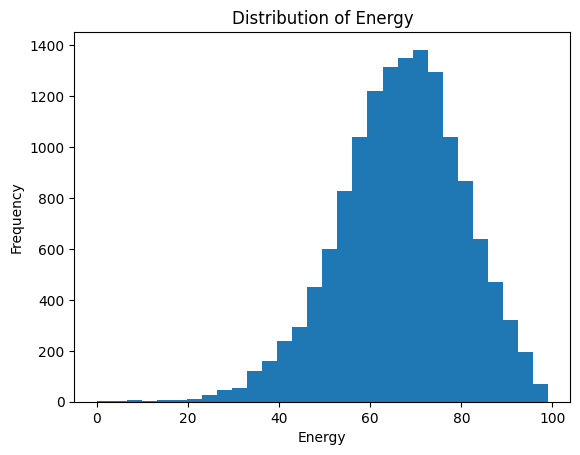

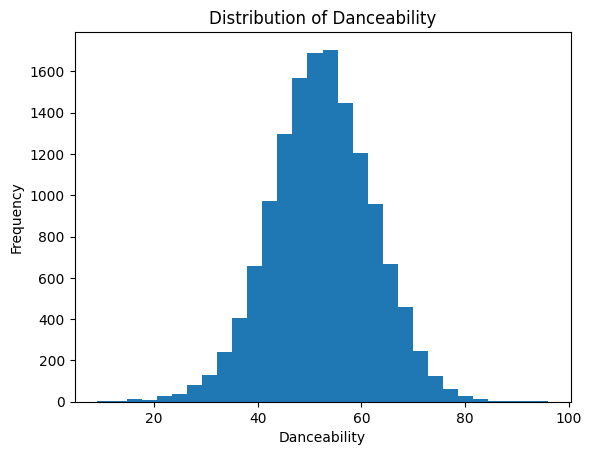

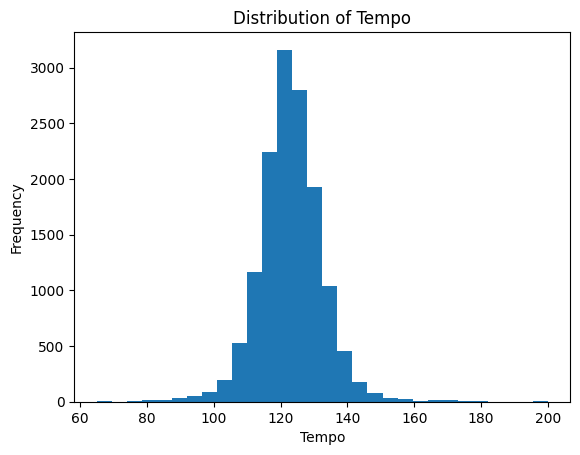

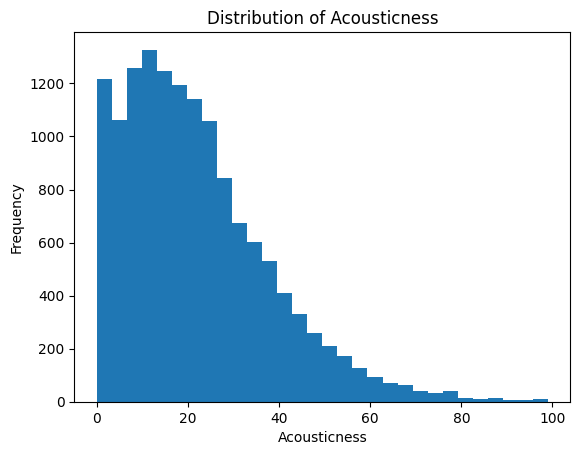

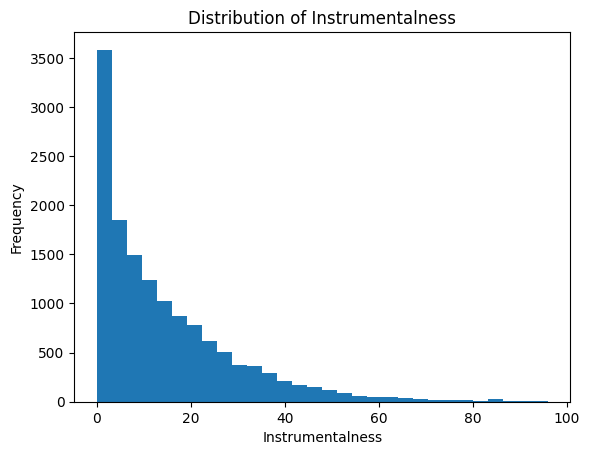

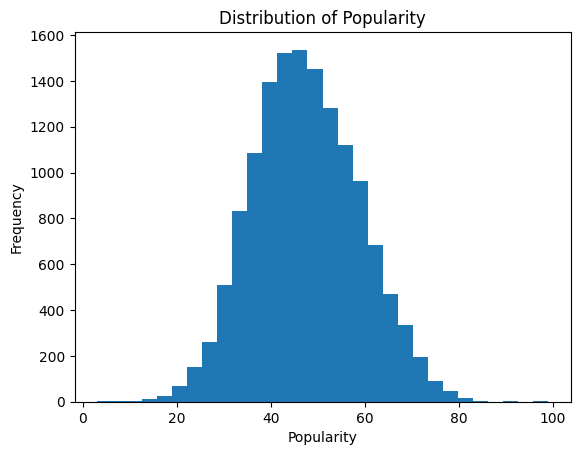

In [92]:
features_to_plot = ["Energy", "Danceability", "Tempo", "Acousticness",
                    "Instrumentalness", "Popularity"]

for f in features_to_plot:
    user_features[f].plot.hist(bins=30)
    plt.title(f"Distribution of {f}")
    plt.xlabel(f)
    plt.ylabel("Frequency")
    plt.show()


## Correlation Between Spotify Features

We compute the correlation matrix to examine how Spotify audio features relate to each other.

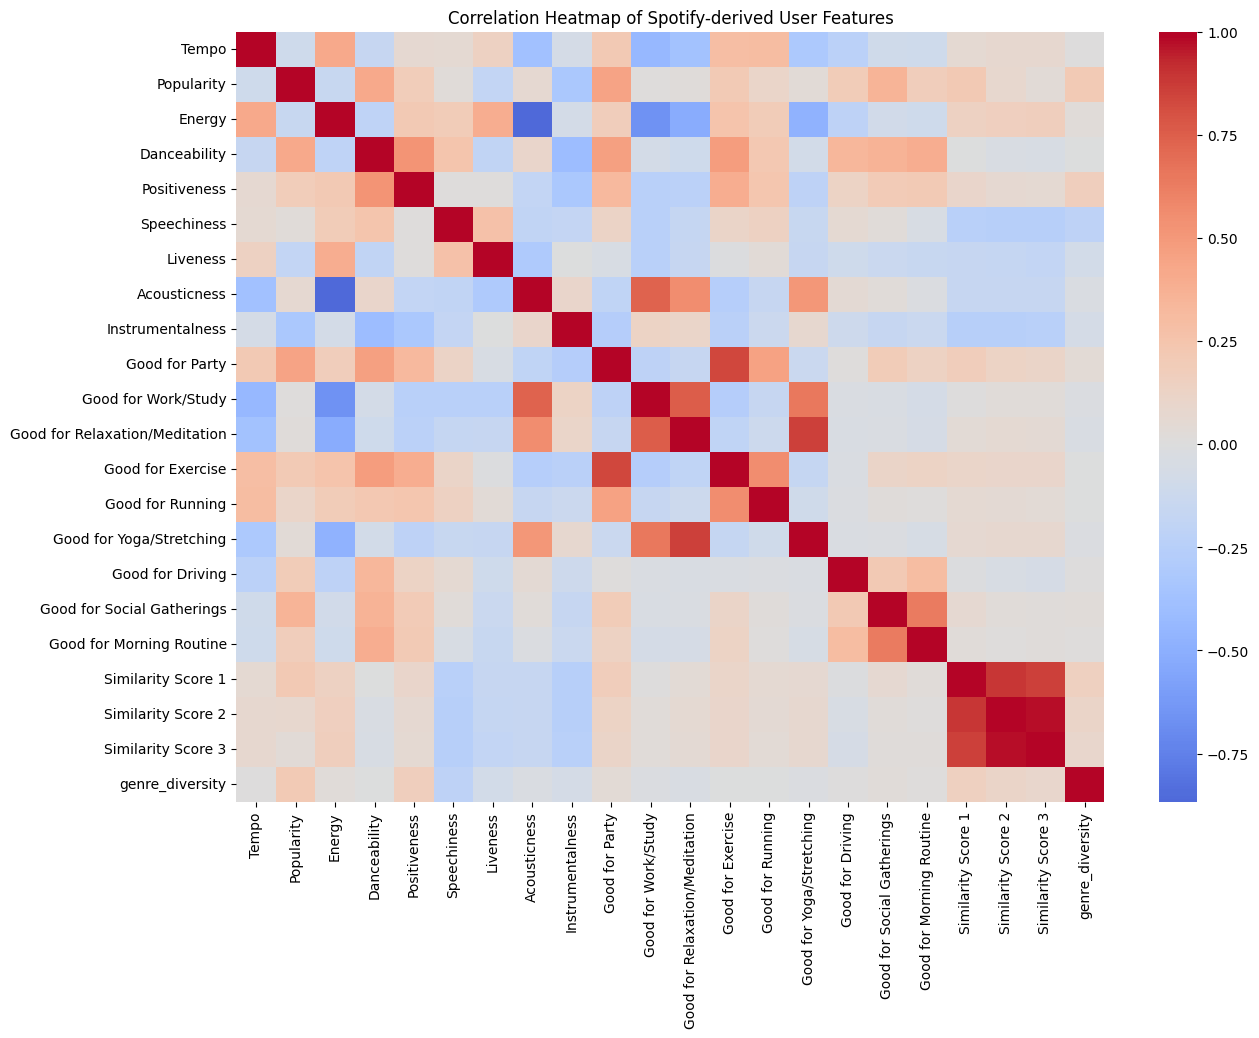

In [93]:
plt.figure(figsize=(14, 10))
sns.heatmap(user_features.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Spotify-derived User Features")
plt.show()


## Distribution of Genre Diversity

We examine how many unique genres each user listens to. This reveals how varied listeners' tastes are.


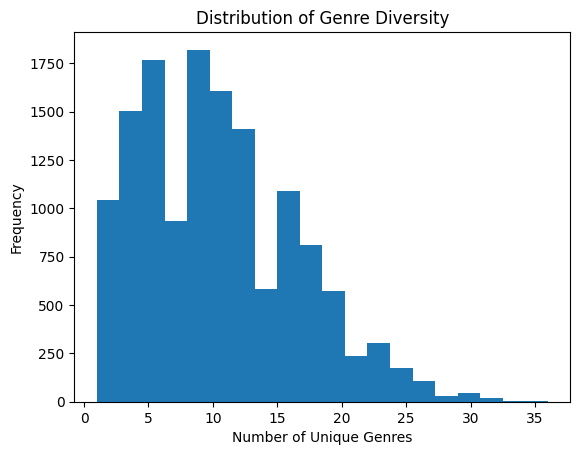

In [94]:
user_features["genre_diversity"].plot.hist(bins=20)
plt.title("Distribution of Genre Diversity")
plt.xlabel("Number of Unique Genres")
plt.show()

## High vs Low Genre Diversity Groups

We split users into high- and low-genre-diversity groups using the median as a cutoff. This creates a categorical variable for comparing user behavior.


In [95]:
threshold = user_features["genre_diversity"].median()
user_features["high_genre_diversity"] = (user_features["genre_diversity"] > threshold).astype(int)

## Relationship Between Genre Diversity and Audio Features

We use scatterplots to explore how genre diversity relates to Spotify audio features such as Energy.


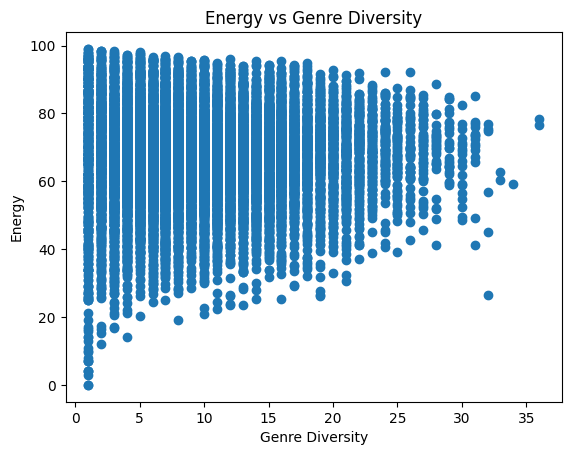

In [96]:
plt.scatter(user_features["genre_diversity"], user_features["Energy"])
plt.xlabel("Genre Diversity")
plt.ylabel("Energy")
plt.title("Energy vs Genre Diversity")
plt.show()


## Comparing High vs Low Genre Diversity Users

Using boxplots, we compare Spotify features between high- and low-diversity users to identify possible behavioral differences.


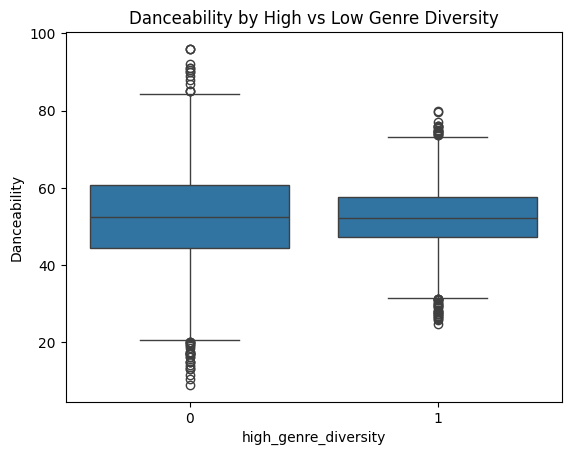

In [97]:
sns.boxplot(x="high_genre_diversity", y="Danceability", data=user_features)
plt.title("Danceability by High vs Low Genre Diversity")
plt.show()
